In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [13]:
# Step 1: Create the dataset
np.random.seed(42)

# Generate 500 data points for area (between 500 and 3500 square feet)
area = np.random.randint(500, 3500, size=500)

# Generate price using a linear relationship with some noise
# Let's assume price = 50 + 0.15 * area + noise
noise = np.random.normal(0, 50, size=500)
price = 50 + 0.15 * area + noise

In [14]:
# Create a DataFrame
data = pd.DataFrame({'Area': area, 'Price': price})
data.head()

,Area,Price
0,1360,254.090681
1,1794,356.896764
2,1630,391.177131
3,1595,309.943742
4,2138,399.088418


In [15]:
# Step 2: Train the Linear Regression model
# Split the data into training and testing sets
X = data[['Area']]
y = data['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [17]:
# Step 3: Evaluate the model
# Make predictions on the test set
y_pred = model.predict(X_test)

In [18]:
# Calculate Mean Squared Error (MSE) and R^2 score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [19]:
print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")

Mean Squared Error: 3034.67
R^2 Score: 0.83


In [20]:
# Step 4: Predict the price for 5 new houses
X_pred = [600, 1200, 1800, 2400, 3000]
new_areas = np.array(X_pred).reshape(-1, 1)
predicted_prices = model.predict(new_areas)

# Display predictions
predicted_prices

C:\Users\thein\anaconda3\envs\Data\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([148.57973577, 236.37052706, 324.16131834, 411.95210963,
       499.74290091])

Predicted price for a house with area 600 sq ft: $148.58k
Predicted price for a house with area 1200 sq ft: $236.37k
Predicted price for a house with area 1800 sq ft: $324.16k
Predicted price for a house with area 2400 sq ft: $411.95k
Predicted price for a house with area 3000 sq ft: $499.74k


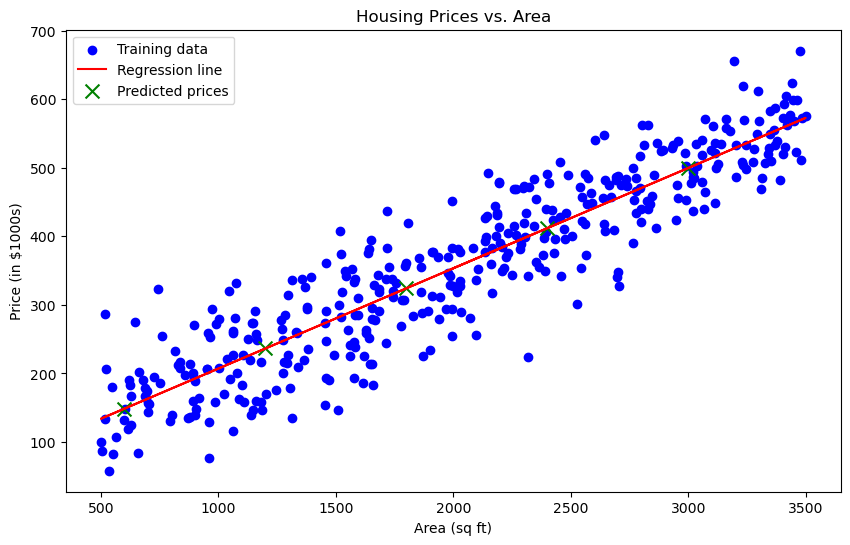

In [21]:
for area, price in zip(new_areas.flatten(), predicted_prices):
    print(f"Predicted price for a house with area {area} sq ft: ${price:.2f}k")

# Plotting the training data and the regression line
plt.figure(figsize=(10, 6))

# Scatter plot of the training data
plt.scatter(X_train, y_train, color='blue', label='Training data')

# Plot the regression line
plt.plot(X_train, model.predict(X_train), color='red', label='Regression line')

# Plot the predictions for the new areas
plt.scatter(new_areas, predicted_prices, color='green', marker='x', s=100, label='Predicted prices')

plt.title('Housing Prices vs. Area')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price (in $1000s)')
plt.legend()
plt.show()